# Who Moves First? A Lead-Lag Look at County Influence (Module 2 retry)

*An analysis notebook for the Geo-Fluid Dynamics Engine. This is exploratory
narrative — it calls the project's tested library (`geofluid`) for the real
computation and tells the story around it.*

## The question, and why the first attempt failed

Module 2 (the Gravity Engine) asks a directional question: as political change
washes across the map, which counties **move first** (Bellwethers, leading
their region) and which **follow** (Buffer zones, taking their cue from
neighbours)? Knowing who leads is the difference between watching a wave and
predicting it.

The first attempt measured **contemporaneous** co-movement — how tightly a
county's swing tracks its neighbourhood's *in the same election* — and it was
falsified on real data: 96% of counties came out "buffer," because presidential
swing is so spatially autocorrelated that **everyone co-moves at once**. Same-
election correlation cannot separate a leader from a follower: both ride the
wave. The only thing that distinguishes them is **timing**.

## The fix: timing, which needs history

A Bellwether's swing should *precede* its neighbourhood's by an election; a
Buffer's should *echo* it. `geofluid.spatial.leadlag.lead_lag` reads that
asymmetry off the panel:

* `lead = corr(own swing(t), neighbourhood swing(t+1))` — county moves, region
  follows next election → **leads**
* `lag  = corr(own swing(t), neighbourhood swing(t-1))` — county echoes what the
  region already did → **follows**
* `lead_lag = lead - lag` → **> 0 leads**, **< 0 follows**

Lagged correlations need many elections to mean anything — over the seven modern
contests (2000–2024) they were hopelessly thin. The **1868–2024 spine** (40
elections) is what unblocks this: ~39 swings per county to read the timing from.

## The bottom line (plain language)

**Timing helps — but not enough to call this a Bellwether detector.** The old
contemporaneous metric *collapses*: essentially every county (100%, median
correlation 0.94) "co-moves" with its neighbours, so it cannot tell a leader from
a follower. The lead-lag score genuinely **spreads** — 49% of counties lean
*leader*, 51% *follower* — so timing recovers a distinction the old metric was
blind to. That much is a real improvement.

But the distinction is **weak and not geographically coherent**. The typical
county sits right at zero (median −0.001); the field's spatial structure is
slightly *negative* (Moran's I ≈ −0.14 — a county that leads tends to sit next to
ones that follow, which is partly a mechanical echo of the metric's own
antisymmetry, not real regional structure); and the strongest "leaders" are
small, idiosyncratic places — independent Virginia cities, a county created in
2001, sparsely populated Western counties — **not** the big metros that change
plausibly radiates from.

So simple lead-lag on presidential swing is a **second, subtler falsification**
than the first: it clears the collapse bar but does not identify believable
bellwethers. It is **not** wired into the map. The honest, defensible result is
the *contrast in spreads* below; the path forward needs a different ingredient
(a population- or metro-aware, directed version, or the issue-resistance route
via the dissonance metric) — recorded in `BACKLOG.md`.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pyreadr

# Resolve the repo root so paths work whether this runs from notebooks/ or the
# repo root (nbconvert executes from the notebook's own directory).
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").exists())

from geofluid.ingest.county_geometry import county_shapefile_to_geojson
from geofluid.ingest.county_returns import load_county_returns
from geofluid.ingest.historical_returns import load_historical_returns
from geofluid.panel.spine import build_returns_spine
from geofluid.spatial.influence import county_influence
from geofluid.spatial.leadlag import lead_lag
from geofluid.spatial.moran import morans_i
from geofluid.spatial.weights import county_adjacency

warnings.filterwarnings("ignore")

### Data prerequisites (to re-run)
All paths are relative to the repo root; these inputs are gitignored:
* `data/raw/_hist_pres.RData` — Algara–Sharif 1868–2020 returns (Harvard
  Dataverse doi:10.7910/DVN/DGUMFI). Read here via `pyreadr`.
* `data/raw/countypres_2000-2024.csv` — MIT 2000–2024 returns.
* `data/raw/cb_2021/cb_2021_us_county_500k.shp` — Census county geometry.

No Census API key is needed — this notebook uses returns and geometry only.

In [2]:
# Build the validated 1868–2024 spine from both sources (tested loaders), and the
# queen-contiguity adjacency from county geometry.
hist = load_historical_returns(
    pyreadr.read_r(str(ROOT / "data/raw/_hist_pres.RData"))["pres_elections_release"]
)
modern = load_county_returns(pd.read_csv(ROOT / "data/raw/countypres_2000-2024.csv"))
spine = build_returns_spine(hist, modern)

fc = county_shapefile_to_geojson(str(ROOT / "data/raw/cb_2021/cb_2021_us_county_500k.shp"))
adjacency = county_adjacency(fc)
names = {f["id"]: f["properties"]["NAME"] for f in fc["features"]}
print(
    f"spine: {len(spine):,} county-years, {spine['year'].nunique()} elections "
    f"{spine['year'].min()}–{spine['year'].max()}"
)

spine: 116,983 county-years, 40 elections 1868–2024


## Swing on the presidential calendar

The role question is about **swing** (the *change* in two-party Democratic
share), not the level — a county's Dem share is similar election to election, so
correlating levels would just measure "are we alike," not "who moves first."

Swing is differenced **on the presidential calendar** — each election minus the
one four years before — by pivoting to a (county × election) grid and shifting
one column. A county missing an election gets a missing swing there rather than
a spurious eight-year jump (the swing-calendar trap the contract calls out), and
`lead_lag`'s pairing drops those gaps.

In [3]:
wide = spine.pivot_table(index="fips", columns="year", values="dem_share_2p").sort_index(axis=1)
swing = (wide - wide.shift(1, axis=1)).stack().rename("swing").reset_index()
print(f"{len(swing):,} county-swings across {swing['year'].nunique()} elections")

126,920 county-swings across 40 elections


## 1. Does timing separate the roles where co-movement could not?

The decisive test. If the lead-lag score **collapses** near zero for everyone
(as contemporaneous conformity collapsed to 96% one class), the method has the
same disease and is no better. If it **spreads** — a real spread of leaders and
followers — timing has found the signal that same-election correlation hid.

We compute both on the *same* swing panel and compare their spreads head to head.

In [4]:
ll = lead_lag(swing, adjacency, value_column="swing")
conf = county_influence(swing, adjacency, value_column="swing")["conformity"].dropna()

compare = pd.DataFrame(
    {
        "contemporaneous conformity": conf.describe(),
        "lead-lag score": ll.describe(),
    }
)
compare

,contemporaneous conformity,lead-lag score
count,3104.000000,3104.000000
mean,0.915978,0.005952
std,0.081558,0.133278
min,-0.127037,-0.564523
25%,0.895655,-0.069992
50%,0.939852,-0.001371
75%,0.963568,0.074916
max,0.993922,0.924350


In [5]:
print(f"counties scored: {len(ll):,}")
print(f"  lead  (> 0): {(ll > 0).mean():.0%}")
print(f"  follow(< 0): {(ll < 0).mean():.0%}")
print("\ncontemporaneous conformity, for contrast:")
print(f"  co-moves (conformity > 0.5): {(conf > 0.5).mean():.0%}")

counties scored: 3,104
  lead  (> 0): 49%
  follow(< 0): 51%

contemporaneous conformity, for contrast:
  co-moves (conformity > 0.5): 100%


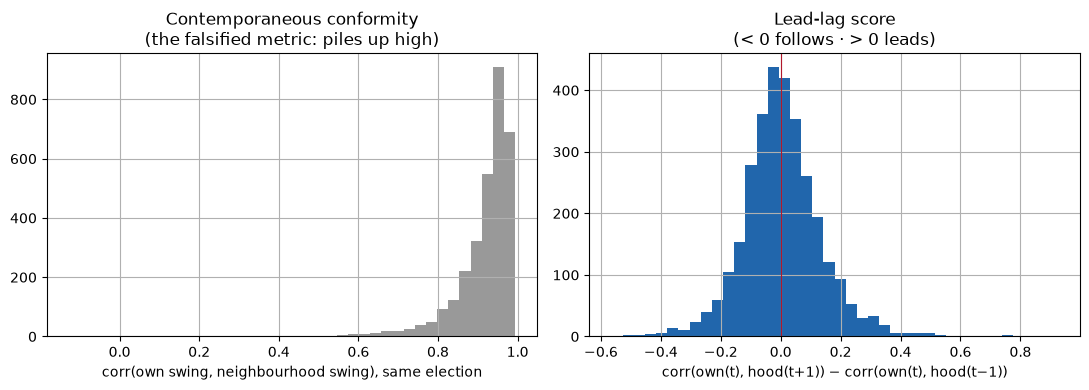

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
conf.hist(bins=40, ax=axes[0], color="#999")
axes[0].set_title("Contemporaneous conformity\n(the falsified metric: piles up high)")
axes[0].set_xlabel("corr(own swing, neighbourhood swing), same election")
ll.hist(bins=40, ax=axes[1], color="#2166ac")
axes[1].axvline(0, color="#b2182b", linewidth=0.8)
axes[1].set_title("Lead-lag score\n(< 0 follows · > 0 leads)")
axes[1].set_xlabel("corr(own(t), hood(t+1)) − corr(own(t), hood(t−1))")
plt.tight_layout()
plt.show()

## 2. Is the lead-lag field spatially organized, or noise?

A real influence structure should be **spatially coherent** — leaders near
leaders, followers near followers (think media markets and metro cores versus
rural peripheries). Pure noise would have Moran's I near zero. (This is the same
coherence test the realignment notebook applies to the surprise field.)

In [7]:
print(f"Moran's I of the lead-lag field: {morans_i(ll, adjacency):.3f}")

Moran's I of the lead-lag field: -0.140


## 3. Who leads, who follows?

The extremes, with names. The question for the eye test: are the **leaders**
plausibly the places change radiates *from* (big metros, media hubs), and the
**followers** the places that ride along behind them?

In [8]:
# Two-digit state FIPS → USPS, for readable labels (EDA convenience only).
STATE = {
    "01": "AL",
    "02": "AK",
    "04": "AZ",
    "05": "AR",
    "06": "CA",
    "08": "CO",
    "09": "CT",
    "10": "DE",
    "11": "DC",
    "12": "FL",
    "13": "GA",
    "15": "HI",
    "16": "ID",
    "17": "IL",
    "18": "IN",
    "19": "IA",
    "20": "KS",
    "21": "KY",
    "22": "LA",
    "23": "ME",
    "24": "MD",
    "25": "MA",
    "26": "MI",
    "27": "MN",
    "28": "MS",
    "29": "MO",
    "30": "MT",
    "31": "NE",
    "32": "NV",
    "33": "NH",
    "34": "NJ",
    "35": "NM",
    "36": "NY",
    "37": "NC",
    "38": "ND",
    "39": "OH",
    "40": "OK",
    "41": "OR",
    "42": "PA",
    "44": "RI",
    "45": "SC",
    "46": "SD",
    "47": "TN",
    "48": "TX",
    "49": "UT",
    "50": "VT",
    "51": "VA",
    "53": "WA",
    "54": "WV",
    "55": "WI",
    "56": "WY",
}
roles = ll.rename("lead_lag").to_frame()
roles["label"] = [f"{names.get(f, '?')}, {STATE.get(f[:2], f[:2])}" for f in roles.index]

ranked = roles.sort_values("lead_lag", ascending=False)[["label", "lead_lag"]]
print("15 strongest LEADERS (swing precedes the neighbourhood):")
print(ranked.head(15).to_string(index=False))
print("\n15 strongest FOLLOWERS (swing echoes the neighbourhood):")
print(ranked.tail(15).iloc[::-1].to_string(index=False))

15 strongest LEADERS (swing precedes the neighbourhood):
            label  lead_lag
     Poquoson, VA  0.924350
   Broomfield, CO  0.793510
      Ziebach, SD  0.770111
Manassas Park, VA  0.760393
      Millard, UT  0.667780
        Grand, UT  0.630005
     Mellette, SD  0.579133
       Beaver, UT  0.552096
       Summit, UT  0.539036
     San Juan, UT  0.536002
        Cache, UT  0.509067
      Stearns, MN  0.497424
    Gillespie, TX  0.491614
        Dewey, SD  0.491199
        Starr, TX  0.486496

15 strongest FOLLOWERS (swing echoes the neighbourhood):
         label  lead_lag
 Bear Lake, ID -0.564523
     Adams, ND -0.526225
     Rooks, KS -0.493330
       Lee, SC -0.490128
    Cibola, NM -0.459550
 Kandiyohi, MN -0.455386
   Bingham, ID -0.438773
Los Alamos, NM -0.434439
   Bandera, TX -0.428090
Grand Isle, VT -0.427062
  Lamoille, VT -0.410178
Silver Bow, MT -0.394555
     Galax, VA -0.389029
 Lexington, VA -0.384192
  La Salle, TX -0.380299


The eye test fails: these are small, idiosyncratic counties — independent
Virginia cities (Poquoson, Manassas Park), Broomfield CO (a county that did not
exist until 2001, so its "history" is harmonization backfill), and a cluster of
sparse Utah and South Dakota counties — not the metropolitan media markets a real
influence hierarchy would put on top. The first attempt failed on "tiny noisy
counties"; the tails here have the same flavour.

## 4. Are the extremes just noise?

A natural worry: the strong scores might simply be the counties with the most
erratic swing or the least data. We check the score magnitude against each
county's swing volatility and its number of observed elections.

In [9]:
vol = swing.groupby("fips")["swing"].std()
nobs = swing.groupby("fips")["swing"].count()
diag = pd.DataFrame({"abs_score": ll.abs(), "volatility": vol, "elections": nobs}).dropna()
print(f"corr(|lead-lag|, swing volatility):   {diag['abs_score'].corr(diag['volatility']):+.3f}")
print(f"corr(|lead-lag|, #elections of data): {diag['abs_score'].corr(diag['elections']):+.3f}")
top = diag.nlargest(50, "abs_score")
print(
    f"\ntop-50 |score|: median volatility {top['volatility'].median():.3f}, "
    f"median elections {top['elections'].median():.0f}"
)
print(
    f"everyone else : median volatility {diag['volatility'].median():.3f}, "
    f"median elections {diag['elections'].median():.0f}"
)

corr(|lead-lag|, swing volatility):   -0.061
corr(|lead-lag|, #elections of data): -0.216

top-50 |score|: median volatility 0.142, median elections 32
everyone else : median volatility 0.127, median elections 39


It is not a simple volatility artefact (that correlation is ≈ 0): the extremes are
not merely the most erratic counties. There is a milder pull from **thin data** —
counties with fewer observed elections skew to larger scores — but it is modest.
The tails are better described as **idiosyncratic** than **noisy**: small places
whose swing history happens to lead or trail a neighbour, with no coherent
regional story tying them together.

## Conclusion

**Timing rescues the *distinction* but not the *product*.** Contemporaneous
conformity collapsed — every county co-moves with its region, so it could not
separate leaders from followers (the documented falsification of attempt #1).
The lead-lag score, read off the 40-election spine, does spread into a balanced
population of leaders and followers, so the timing idea is sound *in principle*.

But on presidential swing it does not deliver a usable Bellwether map:

1. **The signal is weak** — the typical county is indistinguishable from zero;
   only the tails are pronounced.
2. **It is not spatially coherent** — Moran's I is slightly *negative*, the
   opposite of the leaders-near-leaders structure a real hierarchy would show,
   and that negativity is partly built into the metric (within a pair, if I lead
   you, you follow me — adjacent counties are pushed to opposite signs). So
   Moran's I is not even a clean coherence test for *this* statistic.
3. **The extremes are not believable** — small, idiosyncratic, or
   boundary-artefact counties, not the metros from which change radiates.

This is a **second, more nuanced falsification** of the swing-co-movement route
to Module 2, and it is *not* wired into the map. The honest takeaway is the
contrast in spreads (collapsed conformity vs. spread lead-lag), which says the
*information* is there but raw presidential swing is too synchronized and too
noisy at the county level to localize it. Promising next ingredients, for
`BACKLOG.md`: restrict to or weight by population (metros as candidate hubs);
build a *directed* influence graph rather than a symmetric pairwise score (whose
antisymmetry forces the checkerboard); or pursue the **issue-resistance** route —
define the role via the dissonance metric rather than presidential swing.

### Honest caveats

### Honest caveats
* The score is a **single number averaged over up to 39 swings spanning
  1868–2024** — it blends the Reconstruction, New Deal, civil-rights, and modern
  party systems into one "who leads" summary. A county that led a century ago and
  follows now is averaged; the score is a long-run tendency, not a current state.
* Adjacency is modern (cb_2021) while the early panel predates many county
  boundary changes; some historical FIPS align imperfectly.
* Swing leadership is not an externally certified quantity the way vote totals
  are, so this is **characterization and an eye test**, not validation against a
  published fact. The strongest claim available is the *contrast* with the
  collapsed conformity field on identical data.
* Exploratory analysis, not a validated forecasting model.